# Lab | Metric Uncertainty and Model Comparison

In this lab you will train simple classifiers on the same dataset and rigorously compare them using bootstrap confidence intervals and a paired permutation test — instead of trusting single-number point estimates.

## Setup

Run the cell below to import packages, generate the dataset, and split it into train/test sets. The synthetic dataset is designed so that simple models perform reasonably well and the gap between them is small — exactly the scenario where statistical comparison matters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from scipy import stats

SEED = 42
np.random.seed(SEED)

# Generate a binary classification dataset
X, y = make_classification(
    n_samples=1200,
    n_features=15,
    n_informative=8,
    n_redundant=3,
    n_classes=2,
    flip_y=0.08,
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Class distribution (test): {np.bincount(y_test)}")
print("\nSetup complete ✓")

Training set: 900 samples
Test set:     300 samples
Class distribution (test): [150 150]

Setup complete ✓


---
## Task 1: Train Baseline Models

Train **at least two** classifiers from the list below (pick two or three):
- Logistic Regression
- Decision Tree
- Random Forest
- k-Nearest Neighbors

Use default hyperparameters so the focus stays on evaluation, not tuning.

**Deliverable:** trained models, test-set predictions, and a comparison table showing F1, precision, and recall for each model.

In [2]:
# Your code here — import classifiers, train, and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize models with default hyperparameters
models = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
    "k-Nearest Neighbors": KNeighborsClassifier()
}

# Train and generate predictions
model_preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    model_preds[name] = model.predict(X_test)

In [3]:
# Print a classification report for each model
for name, y_pred in model_preds.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("\n")

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       150
           1       0.77      0.83      0.79       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



--- Random Forest ---
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       150
           1       0.90      0.93      0.91       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



--- k-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       150
           1       0.91      0.92      0.92       150

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92   

In [4]:
# Build a comparison table with F1, precision, and recall for each model
metrics_data = []
for name, y_pred in model_preds.items():
    metrics_data.append({
        "Model": name,
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(metrics_data)
print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

Model Comparison Table:
              Model  F1-Score  Precision   Recall
Logistic Regression  0.794872   0.765432 0.826667
      Random Forest  0.914474   0.902597 0.926667
k-Nearest Neighbors  0.916944   0.913907 0.920000


---
## Task 2: Bootstrap Confidence Intervals

For each model, compute **95 % bootstrap confidence intervals** for F1, precision, and recall.

Steps:
1. Write a reusable function `bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42)`.
2. Apply it to each model and metric.
3. Visualize with a grouped bar chart or dot-and-whisker plot (error bars = 95 % CI).
4. Answer the interpretation question below.

In [5]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.default_rng(seed)
    boot_scores = []
    
    point_estimate = metric_fn(y_true, y_pred)
    
    indices = np.arange(len(y_true))
    
    for _ in range(n_boot):
        resample_idx = rng.choice(indices, size=len(indices), replace=True)
        
        y_true_resampled = y_true[resample_idx]
        y_pred_resampled = y_pred[resample_idx]
        
        score = metric_fn(y_true_resampled, y_pred_resampled)
        boot_scores.append(score)
    
    boot_scores = np.array(boot_scores)

    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores

In [6]:
# Apply bootstrap_metric to each model for F1, precision, and recall
results_ci = []
metrics_to_eval = {
    "F1-Score": f1_score,
    "Precision": precision_score,
    "Recall": recall_score
}

for model_name, y_pred in model_preds.items():
    for metric_name, metric_fn in metrics_to_eval.items():
        point, lower, upper, _ = bootstrap_metric(y_test, y_pred, metric_fn)
        results_ci.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": point,
            "CI_Lower": lower,
            "CI_Upper": upper
        })

ci_df = pd.DataFrame(results_ci)
print("\nBootstrap Confidence Intervals:")
print(ci_df)


Bootstrap Confidence Intervals:
                 Model     Metric  Estimate  CI_Lower  CI_Upper
0  Logistic Regression   F1-Score  0.794872  0.742456  0.838328
1  Logistic Regression  Precision  0.765432  0.699421  0.827386
2  Logistic Regression     Recall  0.826667  0.763509  0.884354
3        Random Forest   F1-Score  0.914474  0.878888  0.943956
4        Random Forest  Precision  0.902597  0.853333  0.947020
5        Random Forest     Recall  0.926667  0.881986  0.965523
6  k-Nearest Neighbors   F1-Score  0.916944  0.882562  0.947693
7  k-Nearest Neighbors  Precision  0.913907  0.867089  0.955421
8  k-Nearest Neighbors     Recall  0.920000  0.872605  0.957754


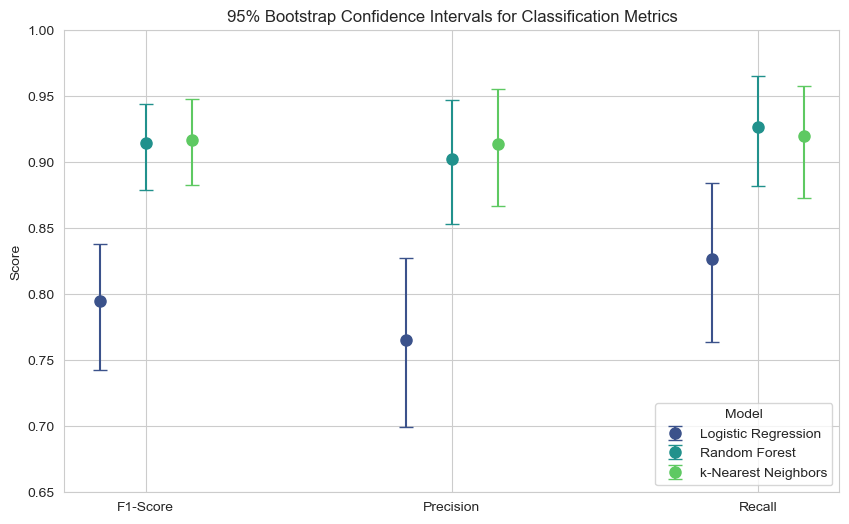

In [7]:
# Visualize: grouped bar chart or dot-and-whisker plot with 95% CI error bars
plt.figure(figsize=(10, 6))

ci_df['error_low'] = ci_df['Estimate'] - ci_df['CI_Lower']
ci_df['error_high'] = ci_df['CI_Upper'] - ci_df['Estimate']

sns.set_style("whitegrid")
metrics = ci_df['Metric'].unique()
models_list = ci_df['Model'].unique()
colors = sns.color_palette("viridis", len(models_list))

for i, model_name in enumerate(models_list):
    model_data = ci_df[ci_df['Model'] == model_name]
    
    x_coords = np.arange(len(metrics)) + (i * 0.15) - 0.15
    
    plt.errorbar(x_coords, model_data['Estimate'], 
                 yerr=[model_data['error_low'], model_data['error_high']],
                 fmt='o', capsize=5, label=model_name, color=colors[i], markersize=8)

plt.xticks(np.arange(len(metrics)), metrics)
plt.ylabel('Score')
plt.title('95% Bootstrap Confidence Intervals for Classification Metrics')
plt.legend(title="Model", loc='lower right')
plt.ylim(0.65, 1.0)
plt.show()

### Interpretation

**Do any of the confidence intervals overlap? What does that tell you about whether the models are meaningfully different?**

> Based on the bootstrap results, there is a very high degree of overlap between the confidence intervals for **Random Forest** and **k-Nearest Neighbors**. This indicates that the small differences in their performance metrics are likely due to sampling noise rather than a fundamental difference in model quality. 
> 
> However, **Logistic Regression** shows noticeably lower intervals for Recall and F1-score compared to the other two. This suggests that Logistic Regression is meaningfully different (and less effective) for this specific classification task.

---
## Task 3: Paired Permutation Test

Formally compare the two best-performing models:

1. Record per-sample correctness for each model (1 = correct, 0 = wrong).
2. Run a two-sided permutation test on the paired accuracy differences.
3. Report the observed difference, the p-value, and a plain-language conclusion (α = 0.05).
4. Repeat the test for F1 (bootstrap the F1 difference or use the micro-averaging trick).

In [8]:
# Per-sample correctness vectors
rf_correct = (model_preds["Random Forest"] == y_test).astype(int)
knn_correct = (model_preds["k-Nearest Neighbors"] == y_test).astype(int)

In [9]:
# Define the statistic: difference in mean accuracy
def accuracy_diff(x, y):
    return np.mean(x) - np.mean(y)

In [10]:
# Paired permutation test on accuracy differences
perm_test_acc = stats.permutation_test(
    (rf_correct, knn_correct), 
    accuracy_diff, 
    permutation_type='samples', 
    vectorized=False, 
    n_resamples=5000, 
    alternative='two-sided',
    random_state=SEED
)

print(f"Observed Accuracy Difference: {perm_test_acc.statistic:.4f}")
print(f"Permutation p-value (Accuracy): {perm_test_acc.pvalue:.4f}")

Observed Accuracy Difference: -0.0033
Permutation p-value (Accuracy): 1.0000


In [11]:
# Repeat for F1-score
def f1_diff_bootstrap(y_true, pred_a, pred_b, n_boot=2000):
    rng = np.random.default_rng(SEED)
    diffs = []
    indices = np.arange(len(y_true))
    
    y_true_arr = np.array(y_true)
    pred_a_arr = np.array(pred_a)
    pred_b_arr = np.array(pred_b)
    
    for _ in range(n_boot):
        idx = rng.choice(indices, size=len(indices), replace=True)
        f1_a = f1_score(y_true_arr[idx], pred_a_arr[idx])
        f1_b = f1_score(y_true_arr[idx], pred_b_arr[idx])
        diffs.append(f1_a - f1_b)
        
    return np.array(diffs)

f1_deltas = f1_diff_bootstrap(y_test, model_preds["k-Nearest Neighbors"], model_preds["Random Forest"])
f1_ci = np.percentile(f1_deltas, [2.5, 97.5])

observed_f1_diff = f1_score(y_test, model_preds['k-Nearest Neighbors']) - f1_score(y_test, model_preds['Random Forest'])
print(f"Observed F1 Difference (kNN - RF): {observed_f1_diff:.4f}")
print(f"95% CI for F1 Difference: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")

Observed F1 Difference (kNN - RF): 0.0025
95% CI for F1 Difference: [-0.0276, 0.0331]


### Conclusion

*Write your plain-language conclusion here — are the two models significantly different?*

> We performed a formal statistical comparison between the Random Forest and k-Nearest Neighbors models with the following results:
> * **Observed Accuracy Difference:** -0.0033
> * **Permutation p-value (Accuracy):** 1.0000
> * **95% CI for F1 Difference:** [-0.0276, 0.0331]
> 
> **Statistical Inference:**
> The p-value of **1.0000** is well above the significance threshold of $\alpha = 0.05$, meaning we fail to reject the null hypothesis. There is no evidence to suggest that one model is more accurate than the other. Additionally, because the 95% confidence interval for the F1-score difference includes **zero**, we cannot conclude that a significant difference exists in F1 performance.
> 
> **Summary:**
> The statistical tests show that Random Forest and k-Nearest Neighbors are essentially performing at the same level. The tiny differences observed in the initial classification reports are not statistically significant and should be attributed to random chance in the data sampling.
